# **ASSIGNMENT 3**: Histogram Equalisation

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [2]:
def load_image(path: str):
    try:
        img = Image.open(path)
        img.load()
        print("Image loaded successfully!")
        return img
    except FileNotFoundError:
        print("Error: Image not found.")
        return None
    except OSError:
        print("Error: File is not a valid image.")
        return None

In [3]:
def verify_convert(img: Image.Image):
    if img.mode == "L":
        print("Image is already 8-bit grayscale.")
        return img
    else:
        print(f"Image mode is {img.mode}. Converting it to 8-bit grayscale ...")
        return img.convert("L")

In [4]:
def print_image(img: Image.Image, title="Image"):
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

In [5]:
def histogram(img: Image.Image, title="Histogram"):
    img_array = np.array(img)
    pixels = img_array.flatten()
    plt.figure(figsize=(8, 4))
    plt.hist(pixels, bins=256, range=(0, 255), color='gray')
    plt.title(title)
    plt.xlabel("Intensity value")
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
def cdf_mapping(img: Image.Image):
    img_array = np.array(img)
    flat = img_array.flatten()
    
    hist = [0] * 256
    for pixel in flat:
        hist[pixel] += 1

    # cdf
    cdf = [0] * 256
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]

    cdf_min = next(x for x in cdf if x != 0)
    total_pixels = len(flat)
    mapping = [0] * 256
    for i in range(256):
        mapping[i] = round((cdf[i] - cdf_min) / (total_pixels - cdf_min) * 255)
        if mapping[i] < 0:
            mapping[i] = 0

    return mapping


In [7]:
def equalization(img: Image.Image, mapping: list):
    if len(mapping) != 256:
        raise ValueError("Mapping must have 256 values (0-255).")
    
    img_array = np.array(img)
    # Apply mapping
    equalized_array = np.array([mapping[p] for p in img_array.flatten()])
    equalized_array = equalized_array.reshape(img_array.shape)
    
    # Convert back to PIL Image
    equalized_img = Image.fromarray(np.uint8(equalized_array))
    return equalized_img

---

### **Image 1**

Image loaded successfully!


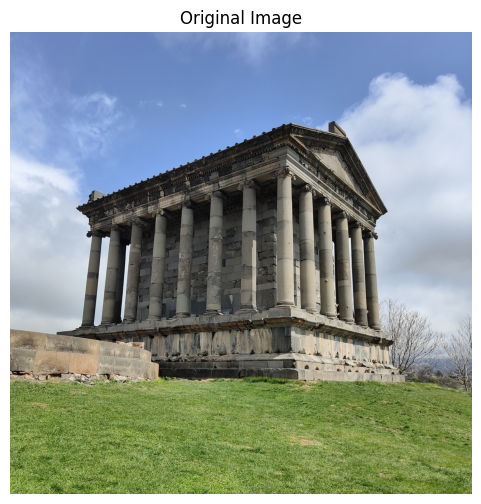

Image mode is RGB. Converting it to 8-bit grayscale ...


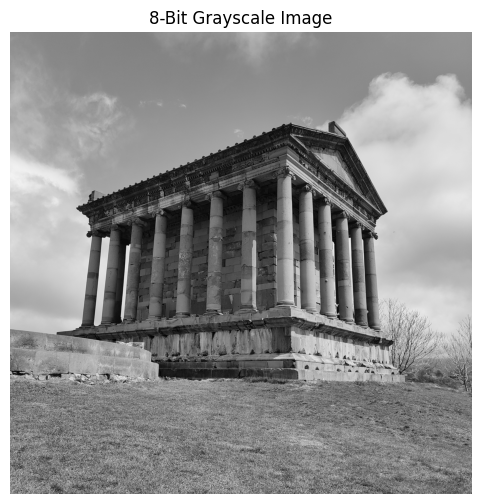

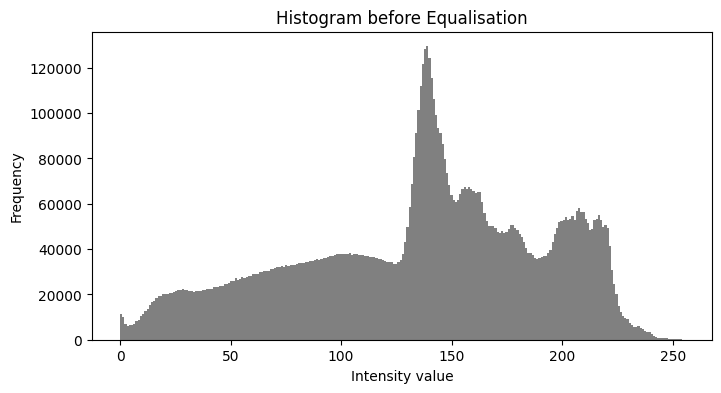

In [ ]:
path = r'..\data\example_image1.jpg'
img = load_image(path)
print_image(img, "Original Image")
img = verify_convert(img)
print_image(img, "8-Bit Grayscale Image")
histogram(img, "Histogram before Equalisation")

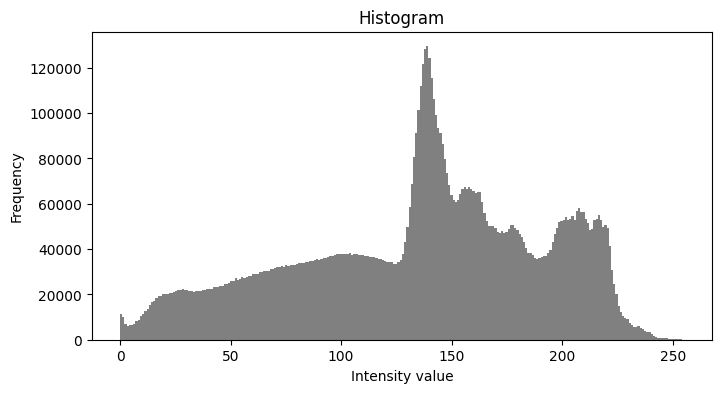

In [9]:
mapping = [i for i in range(256)]
equalised_img = equalization(img, mapping)
histogram(equalised_img)

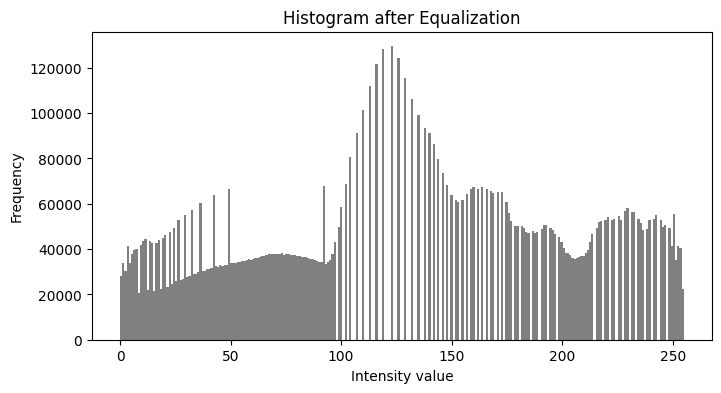

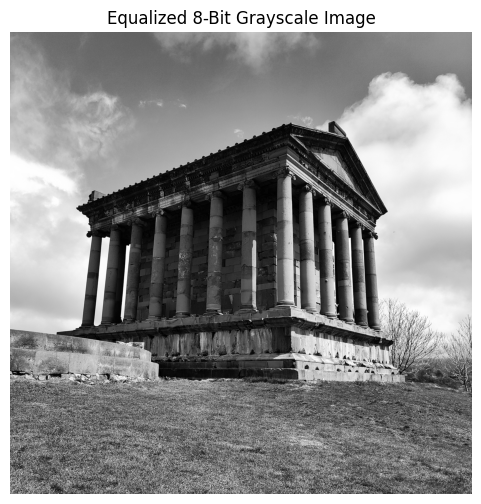

In [10]:
mapping = cdf_mapping(img)
equalised_img = equalization(img, mapping)
histogram(equalised_img, "Histogram after Equalization")
print_image(equalised_img, "Equalized 8-Bit Grayscale Image")

---

### **Image 2**

Image loaded successfully!


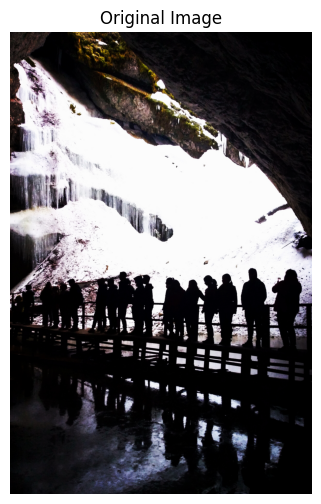

Image mode is RGB. Converting it to 8-bit grayscale ...


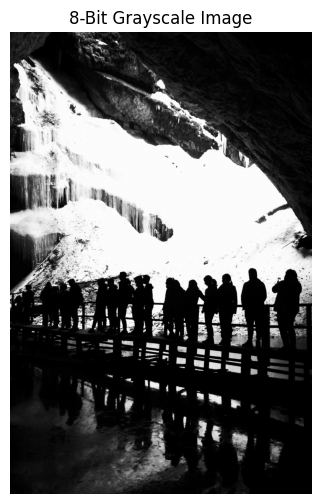

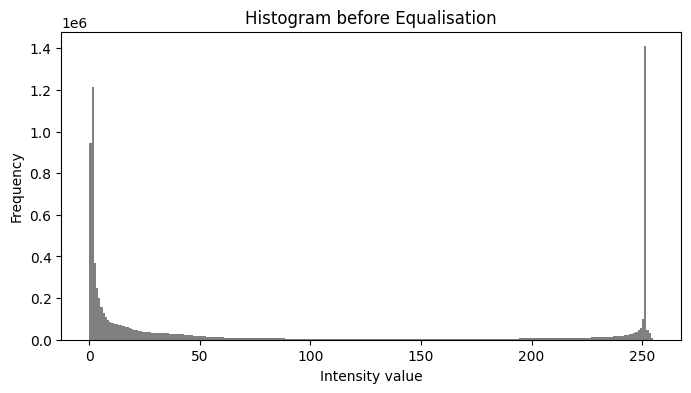

In [ ]:
path = r"..\data\example_image2.jpg"
img = load_image(path)
print_image(img, "Original Image")
img = verify_convert(img)
print_image(img, "8-Bit Grayscale Image")
histogram(img, "Histogram before Equalisation")

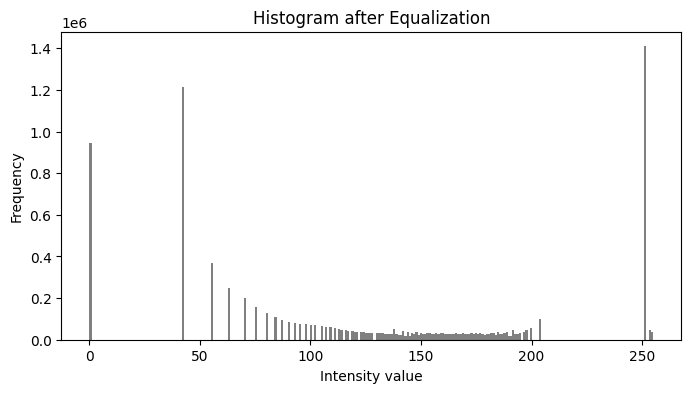

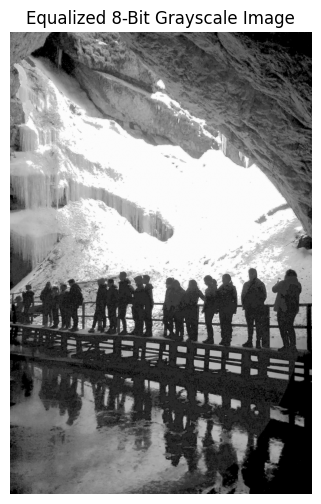

In [12]:
mapping = cdf_mapping(img)
equalised_img = equalization(img, mapping)
histogram(equalised_img, "Histogram after Equalization")
print_image(equalised_img, "Equalized 8-Bit Grayscale Image")

---

### **Image 3**

Image loaded successfully!


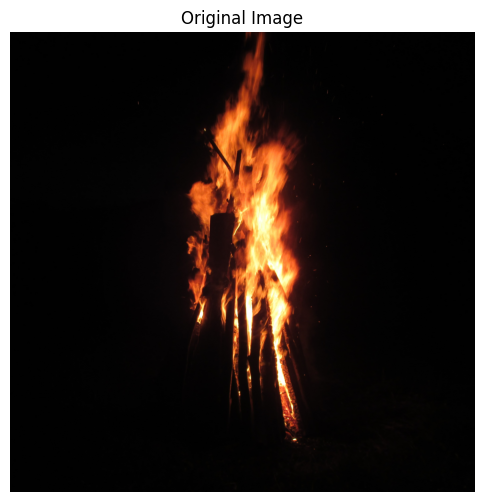

Image mode is RGB. Converting it to 8-bit grayscale ...


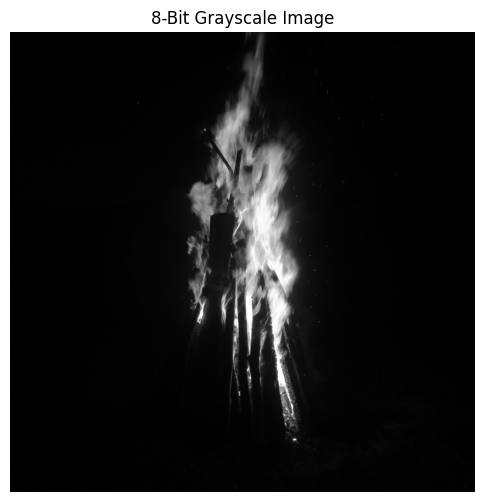

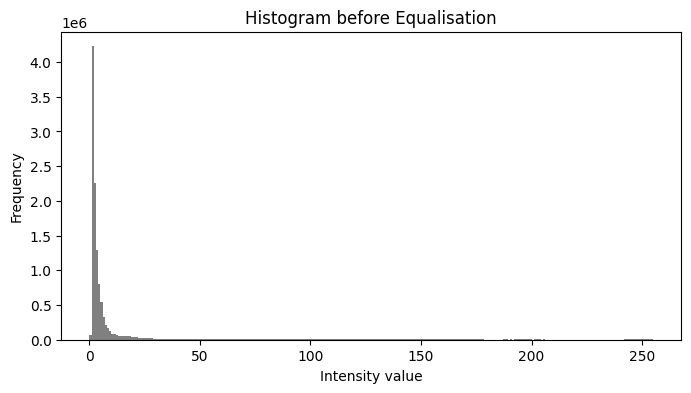

In [ ]:
path = r"..\data\example_image3.JPG"
img = load_image(path)
print_image(img, "Original Image")
img = verify_convert(img)
print_image(img, "8-Bit Grayscale Image")
histogram(img, "Histogram before Equalisation")

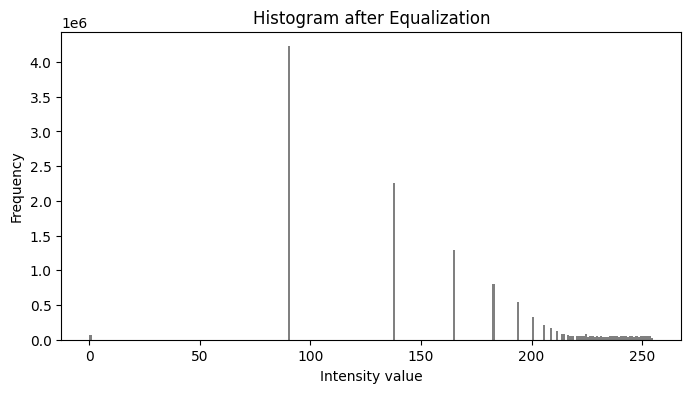

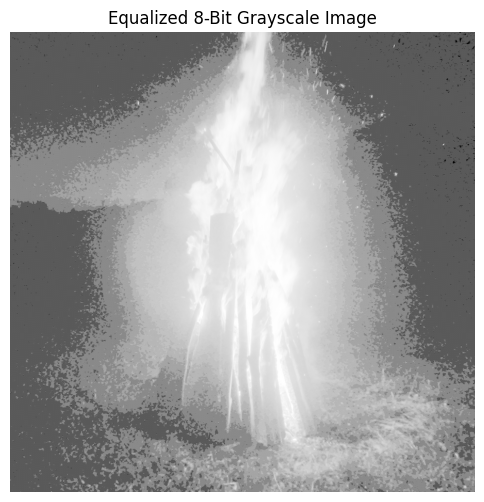

In [14]:
mapping = cdf_mapping(img)
equalised_img = equalization(img, mapping)
histogram(equalised_img, "Histogram after Equalization")
print_image(equalised_img, "Equalized 8-Bit Grayscale Image")

---

### **Image 4**

Image loaded successfully!


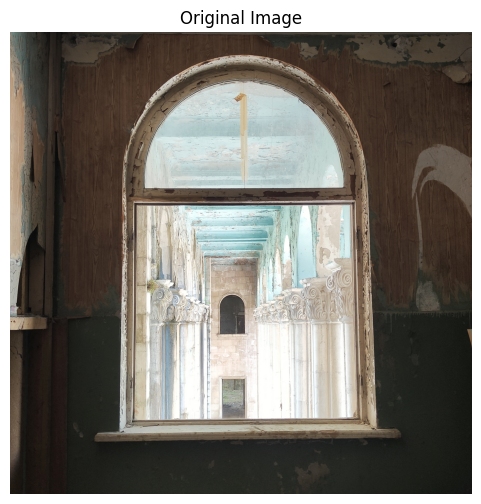

Image mode is RGB. Converting it to 8-bit grayscale ...


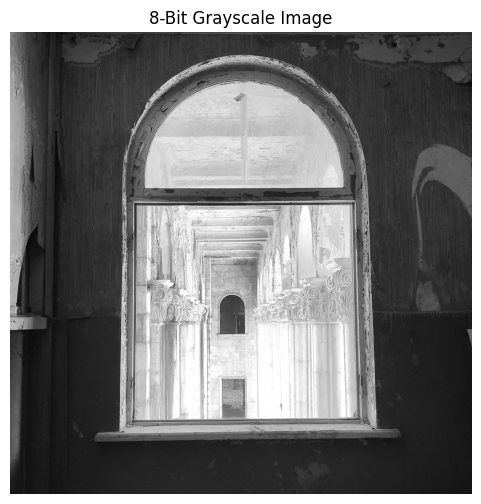

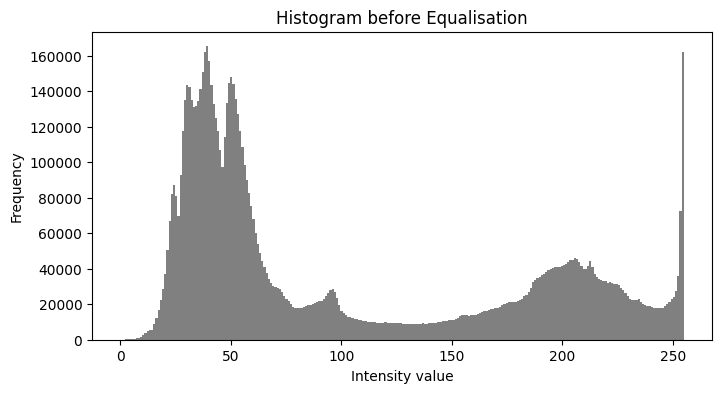

In [ ]:
path = r"..\data\example_image4.jpg"
img = load_image(path)
print_image(img, "Original Image")
img = verify_convert(img)
print_image(img, "8-Bit Grayscale Image")
histogram(img, "Histogram before Equalisation")

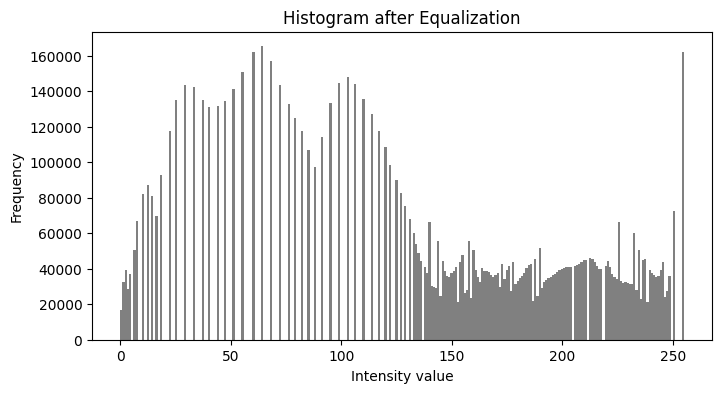

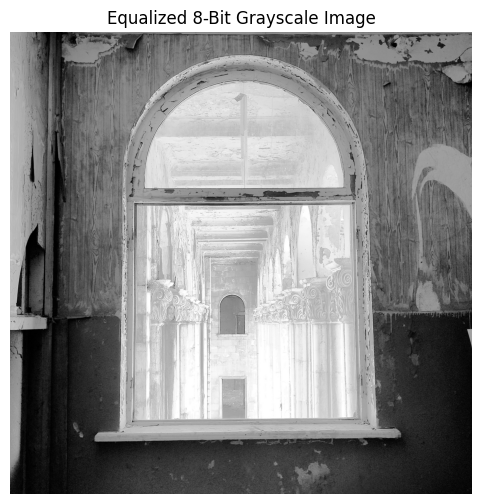

In [16]:
mapping = cdf_mapping(img)
equalised_img = equalization(img, mapping)
histogram(equalised_img, "Histogram after Equalization")
print_image(equalised_img, "Equalized 8-Bit Grayscale Image")